In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

# 1. Настройка окружения
os.makedirs('artifacts/figures', exist_ok=True)
os.makedirs('artifacts/labels', exist_ok=True)

datasets = {
    'ds1': 'data/S07-hw-dataset-01.csv',
    'ds2': 'data/S07-hw-dataset-02.csv',
    'ds4': 'data/S07-hw-dataset-04.csv'
}

all_metrics = {}
best_configs = {}


========== Processing ds1 ==========
Shape: (12000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB
None
Missing values:
 0


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745



========== Processing ds2 ==========
Shape: (8000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB
None
Missing values:
 0


,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076



========== Processing ds4 ==========
Shape: (10000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_a      10000 non-null  object 
 2   cat_b      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   flo

,sample_id,n01,n02,n03,n04,n05,n06,n07,n08,n09,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
count,10000.00000,9826.000000,9811.000000,9801.000000,9808.000000,9799.000000,9817.000000,9796.000000,9806.000000,9805.000000,...,9785.000000,9804.000000,9829.000000,9793.000000,9815.000000,9776.000000,9803.000000,9789.000000,9798.000000,9805.000000
mean,4999.50000,17.348435,-2.057620,7.908302,14.269157,0.900590,5.832787,-0.840875,-4.888128,3.184200,...,-12.716502,-0.506241,8.360226,0.026943,0.039297,-0.037155,0.028512,-0.030738,-0.018685,-0.030254
std,2886.89568,22.578551,19.043410,25.637807,18.815319,20.981294,13.221646,26.583849,15.466271,32.208740,...,37.290305,14.336833,17.754646,26.121335,3.009995,3.020813,3.028106,3.000090,3.014209,3.014573
min,0.00000,-22.437090,-37.546998,-38.136412,-23.374316,-45.914070,-20.650038,-60.297304,-44.464550,-70.904880,...,-89.640783,-35.102360,-25.014050,-49.423300,-11.225848,-14.446922,-10.840777,-11.679259,-11.437909,-11.491223
25%,2499.75000,-3.975438,-14.200552,-8.591513,-1.223379,-5.086756,-4.532057,-13.554720,-17.352641,-11.460490,...,-41.284671,-11.563652,-2.123576,-19.425213,-1.973213,-2.082235,-2.007628,-2.074500,-2.051778,-2.074396
50%,4999.50000,22.042807,-6.532183,0.350400,10.069142,2.413111,7.391953,-2.429024,-7.095546,13.258691,...,-1.145681,2.491416,6.691365,-8.464171,0.037806,-0.033336,0.031588,-0.043127,-0.015441,-0.015903
75%,7499.25000,37.535647,2.092197,30.725630,29.807101,18.398883,13.033076,16.095731,3.909111,20.188426,...,18.916379,11.903004,14.939690,16.861978,2.048648,2.019027,2.056870,1.980217,2.013964,2.031215
max,9999.00000,65.446912,43.326647,60.185729,65.094588,42.527554,39.933274,48.591236,31.335431,64.696045,...,49.157087,22.452135,46.892903,61.540902,11.002135,11.394631,11.936846,10.663960,10.665988,13.755203


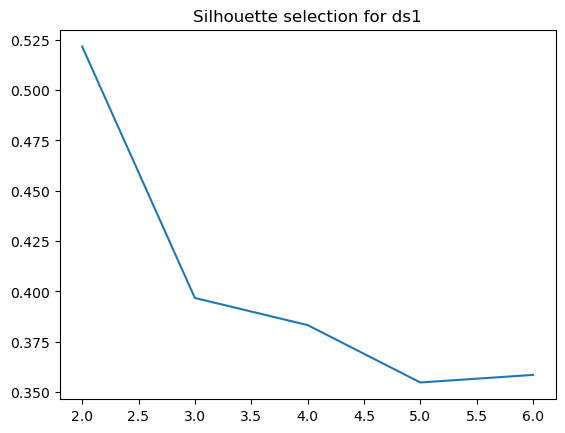

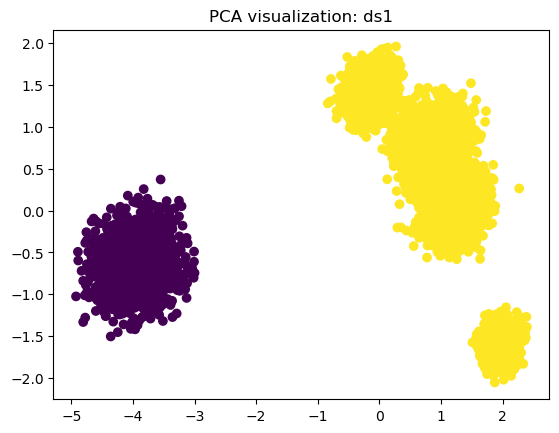

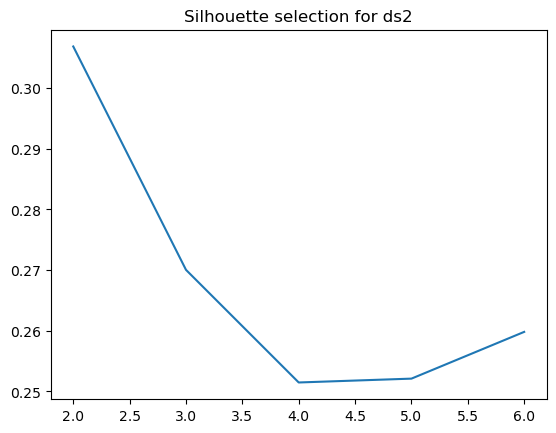

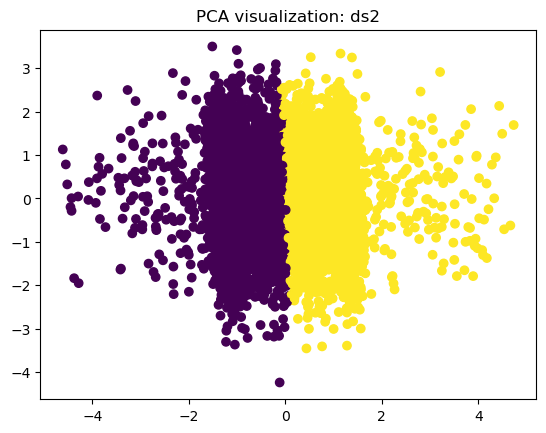

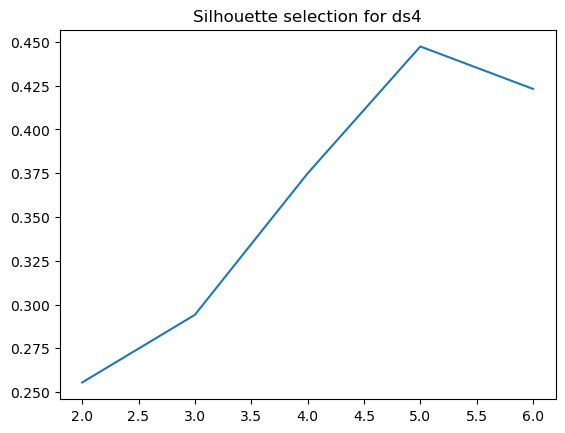

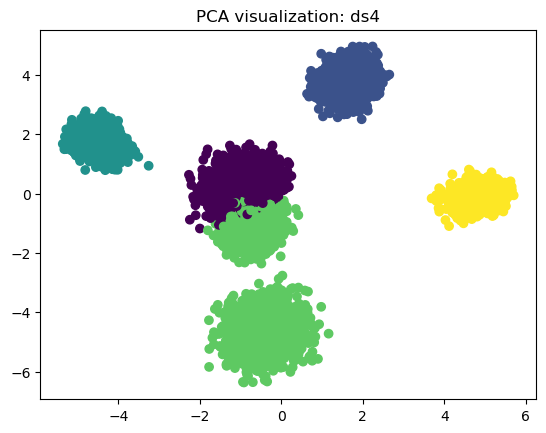

In [8]:
# 2. Основной цикл обработки
for ds_key, path in datasets.items():
    print(f"\n{'='*10} Processing {ds_key} {'='*10}")
    df = pd.read_csv(path)
    
    # EDA (Обязательные сигналы для проверки) 
    print(f"Shape: {df.shape}")
    print(df.info())
    print("Missing values:\n", df.isna().sum().sum())
    display(df.describe()) # Важно для логов ноутбука
    
    # Подготовка данных (исключаем ID)
    X = df.drop(columns=['sample_id'])
    
    # Препроцессинг (ColumnTransformer)
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    # Использование SimpleImputer и StandardScaler обязательно!
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
    
    X_pre = preprocessor.fit_transform(X)
    
    # Кластеризация и подбор параметров
    # 1. KMeans (подбор K)
    best_sil = -1
    best_k = 2
    for k in range(2, 7):
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pre)
        sil = silhouette_score(X_pre, km.labels_)
        if sil > best_sil:
            best_sil = sil
            best_k = k
            
    # Сохраняем график подбора (Артефакты 1-3)
    plt.figure()
    plt.plot(range(2, 7), [silhouette_score(X_pre, KMeans(n_clusters=i, n_init=10, random_state=42).fit(X_pre).labels_) for i in range(2, 7)])
    plt.title(f'Silhouette selection for {ds_key}')
    plt.savefig(f'artifacts/figures/{ds_key}_param_selection.png')
    
    # 2. Второй алгоритм (DBSCAN для плотности или Agglomerative для иерархии)
    if ds_key == 'ds2':
        alt_model = AgglomerativeClustering(n_clusters=2, linkage='ward')
    else:
        alt_model = DBSCAN(eps=0.5, min_samples=5)
    
    alt_labels = alt_model.fit_predict(X_pre)
    km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_pre)
    
    # Считаем метрики для KMeans
    m = {
        'silhouette': silhouette_score(X_pre, km_final.labels_),
        'davies_bouldin': davies_bouldin_score(X_pre, km_final.labels_),
        'calinski_harabasz': calinski_harabasz_score(X_pre, km_final.labels_)
    }
    all_metrics[ds_key] = m
    best_configs[ds_key] = {"method": "KMeans", "k": best_k}
    
    # Визуализация PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_pre)
    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_final.labels_, cmap='viridis')
    plt.title(f'PCA visualization: {ds_key}')
    plt.savefig(f'artifacts/figures/{ds_key}_pca.png')
    
    # Сохранение меток
    pd.DataFrame({
        'sample_id': df['sample_id'],
        'cluster_label': km_final.labels_
    }).to_csv(f'artifacts/labels/labels_hw07_{ds_key}.csv', index=False)

In [9]:
# 3. Устойчивость (на DS1)
X_s1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
]).fit_transform(pd.read_csv(datasets['ds1']).drop(columns=['sample_id']))

r1 = KMeans(n_clusters=3, n_init=1, random_state=1).fit_predict(X_s1)
r2 = KMeans(n_clusters=3, n_init=1, random_state=42).fit_predict(X_s1)
print(f"\nStability ARI (DS1): {adjusted_rand_score(r1, r2):.4f}")



Stability ARI (DS1): 0.5041


In [10]:
# 4. Сохранение JSON
with open('artifacts/metrics_summary.json', 'w') as f: json.dump(all_metrics, f)
with open('artifacts/best_configs.json', 'w') as f: json.dump(best_configs, f)